In [1]:
import os, datetime, sys, time, traceback

import pandas as pd
import numpy as np
import pickle as pkl
import multiprocessing as mp
import matplotlib.pyplot as plt

from statsmodels.distributions.empirical_distribution import ECDF
from skfda.exploratory.depth import ModifiedBandDepth
from functional_utils import _confidence_bands_from_eCDF
from scipy import stats
from functools import partial

from sklearn.neighbors import KernelDensity

from ffc_utils import (_fknn_forecast_dynamic_update,
                       _functional_downsampling, 
                       _focal_curve_envelope, 
                       _functional_confidence_band,
                       _silverman_rule)

from scores_utils import _empirical_PIT, _KS

path_to_data = '/home/gterren/dynamic_update/data'
path_to_validation = '/home/gterren/dynamic_update/validation'
path_to_param = '/home/gterren/dynamic_update/params'
path_to_test = '/home/gterren/dynamic_update/test'

# Calibration experiments setup
resource = 'wind'
method   = 'fusion'

(363, 288, 187) (363, 288, 187)


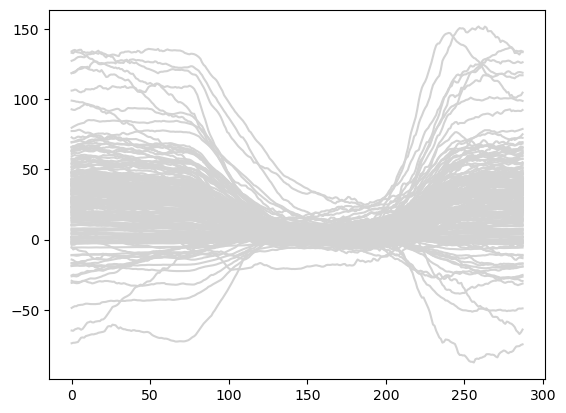

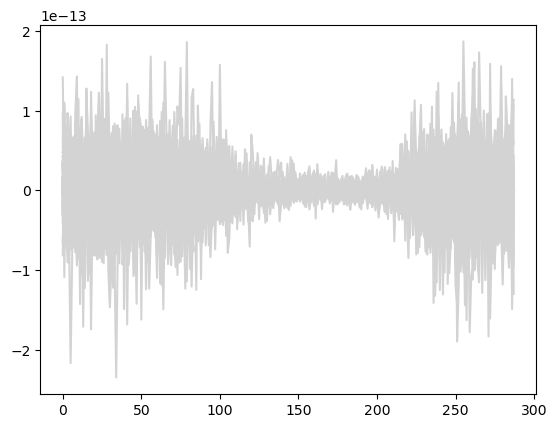

(364, 288, 187) (364, 288, 187)


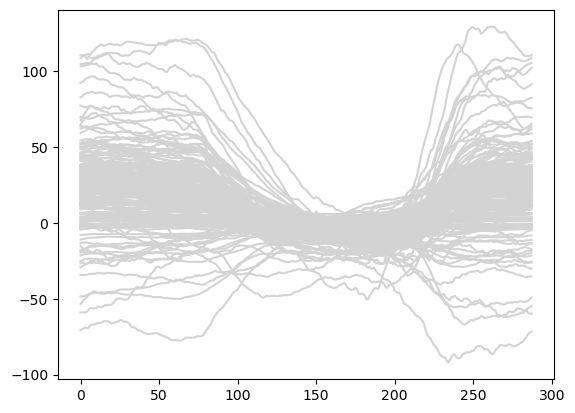

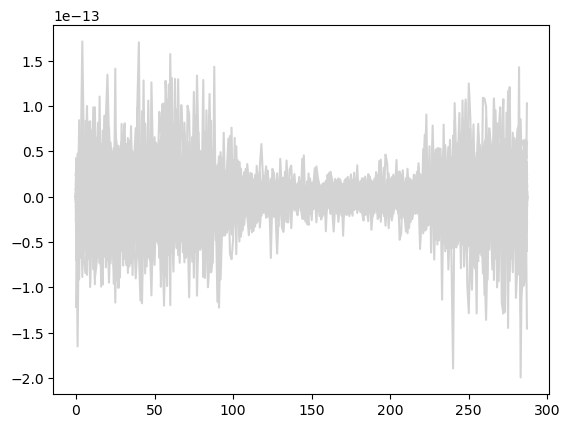

In [2]:
T = 288
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
print(F_tr_.shape, E_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
# print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_lin_ = E_ts_.copy()
E_tr_lin_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(E_tr_lin_.shape, E_ts_lin_.shape)

(363, 288, 187) (363, 288, 187) (363, 288)


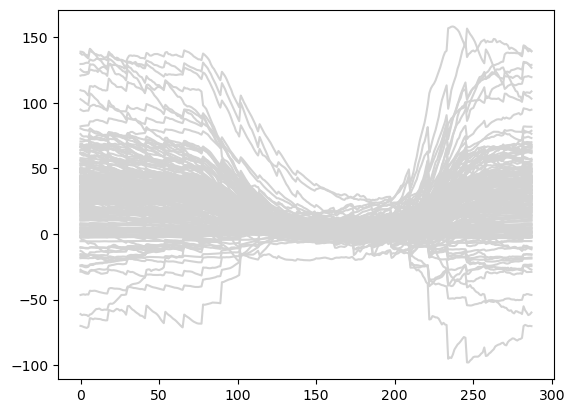

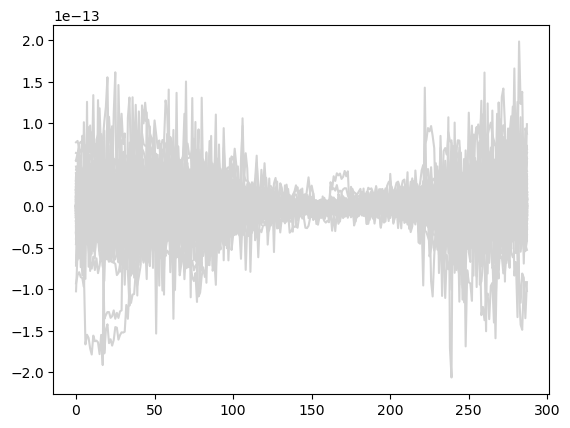

(364, 288, 187) (364, 288, 187) (364, 288)


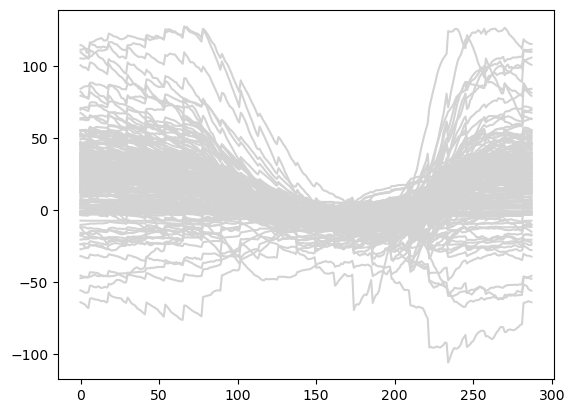

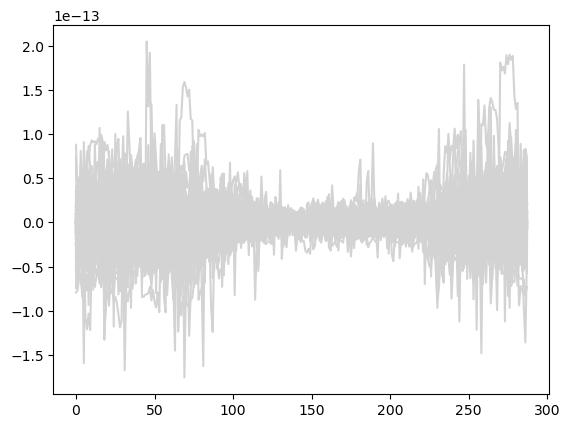

In [3]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
x_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, x_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
x_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, x_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
x_ts_      = x_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]
    
plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()


# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_ = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
x_tr_ = np.concatenate([np.tile(x_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(x_tr_.shape[0])], axis = 0)
F_tr_ = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(x_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
#print(x_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_ts in T_ts_[:, 0]]) - 1
#print(t_tr_.shape, t_ts_.shape)

In [4]:
def _plot_PIT(_ax, u_, bins=10, title="PIT Histogram"):
    """
    Make a PIT histogram with a Uniform(0,1) reference line.
    Uses matplotlib, one chart, no explicit colors.
    """

    # histogram as density so the uniform reference is y=1
    counts_, bins, patches = _ax.hist(u_, 
                                     bins=bins, 
                                     range=(0.0, 1.0), 
                                     density=True, 
                                     edgecolor='black', 
                                     alpha = 0.5)   

    _ax.axhline(1.0, linestyle='--', color='red')
    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, )

    _ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_ylabel("Density")
    _ax.set_title(title)

def _KS(pit_):
    pit_ = np.asarray(pit_, dtype=float)
    pit_ = pit_[np.isfinite(pit_)]
    pit_ = np.clip(pit_, 0.0, 1.0)
    return stats.kstest(pit_, 'uniform').statistic

def _run_ffc(day, asset):

    file_name = f'{asset}-{day}-{time}'
    #print(f'Processing file {file_name}...')

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_ts   = x_ts_[asset, :]
    t_ts   = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    #idx_days_  = np.absolute(t_tr_ - day) < 28
    #idx_hours_ = np.mean(F_tr_[idx_days_, :], axis = 0) > .25

    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.
    
    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                              forget_rate_f = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate = hyper_.loc['lookup_rate'][time],
                                              trust_rate = hyper_.loc['trust_rate'][time],
                                              gamma = hyper_.loc['gamma'][time],
                                              xi = hyper_.loc['xi'][time],
                                              nu = hyper_.loc['nu'][time],
                                              kappa_min = hyper_.loc['kappa_min'][time],
                                              kappa_max = hyper_.loc['kappa_max'][time], 
                                              p_fusion = hyper_.loc['p_fusion'][time], 
                                              idx_hours_ = idx_hours_)

    #M_p_, f_p_ = _bias_correction(M_, _meta['focal_curve'], bias_, time, scale = 0.5)
    M_p_ = M_ 
    f_p_ = _meta['focal_curve'].copy()

    return [M_p_, f_hat_, f_p_, file_name]

def _run_parallel(n_workers = 32, 
                  assets_ = range(5), 
                  indices_ = range(363)):

    M_ = []
    f_hat_ = []
    focal_ = []
    date_ = []
    for asset in assets_:
        with mp.Pool(processes = n_workers) as pool:
            worker = partial(_run_ffc, asset=asset)
            results_ = pool.map(worker, indices_)
        M_ += [result[0] for result in results_]
        f_hat_ += [result[1] for result in results_]
        focal_ += [result[2] for result in results_]
        date_ += [result[3] for result in results_]
    print(len(M_), len(f_hat_), len(focal_), len(date_))
    
    return M_, f_hat_, focal_, date_

                     72       144      216
parameter                                 
forget_rate_f     0.1250    0.125    0.125
forget_rate_e     8.0000    4.000    2.000
lookup_rate     128.0000  128.000  128.000
length_scale_f    0.0100    0.005    0.001
length_scale_e    0.0075    0.025    0.010
trust_rate        0.4000    0.500    0.600
nu               14.0000   12.000   10.000
xi                0.8000    0.700    0.500
gamma            30.0000   50.000   30.000
kappa_min        80.0000  100.000  120.000
kappa_max       175.0000  175.000  175.000
p_fusion          0.6000    0.600    0.600


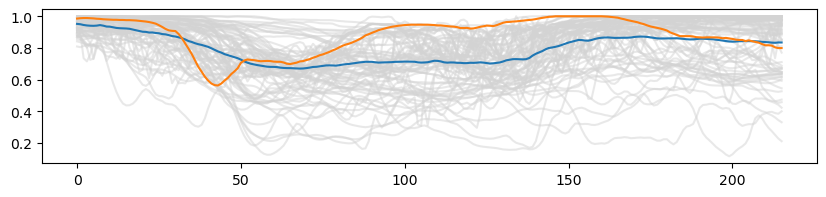

In [5]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)

# hyper_.loc['forget_rate_f'][time] = 0.5
# hyper_.loc['length_scale_f'][time] = 0.0005
#hyper_.loc['xi'][time] = .8
#hyper_.loc['gamma'][time] = 30

print(hyper_)

asset = 0
time = 72
day = 30

# Get functional predictors for a given test
f_ = F_ts_[day, :time, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_ = E_ts_[day, :, asset]
x_ts = x_ts_[asset, :]
t_ts = t_ts_[day]
f_hat_ = F_ts_[day, time:, asset]

# Filter solar hours with loading solar set
idx_days_  = np.absolute(t_tr_ - day) < 7
idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

_meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                          forget_rate_f = hyper_.loc['forget_rate_f'][time],
                                          forget_rate_e = hyper_.loc['forget_rate_e'][time],
                                          length_scale_f = hyper_.loc['length_scale_f'][time],
                                          length_scale_e = hyper_.loc['length_scale_e'][time],
                                          lookup_rate = hyper_.loc['lookup_rate'][time],
                                          trust_rate = hyper_.loc['trust_rate'][time],
                                          nu = hyper_.loc['nu'][time],
                                          gamma = hyper_.loc['gamma'][time],
                                          xi = hyper_.loc['xi'][time],
                                          kappa_min = hyper_.loc['kappa_min'][time],
                                          kappa_max = hyper_.loc['kappa_max'][time], 
                                          p_fusion = hyper_.loc['trust_rate'][time],
                                          idx_hours_ = idx_hours_)

plt.figure(figsize=(10, 2))
plt.plot(M_.T, color = 'lightgray', alpha = 0.5)
plt.plot(_meta['focal_curve'])
plt.plot(f_hat_)
plt.show()

In [6]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

time = 72

M_, f_hat_, focal_, date_ = _run_parallel(n_workers = 72, 
                                          assets_ = range(20, 40, 1), 
                                          indices_ = range(363))

                     72       144      216
parameter                                 
forget_rate_f     0.1250    0.125    0.125
forget_rate_e     8.0000    4.000    2.000
lookup_rate     128.0000  128.000  128.000
length_scale_f    0.0100    0.005    0.001
length_scale_e    0.0075    0.025    0.010
trust_rate        0.4000    0.500    0.600
nu               14.0000   12.000   10.000
xi                0.8000    0.700    0.500
gamma            30.0000   50.000   30.000
kappa_min        80.0000  100.000  120.000
kappa_max       175.0000  175.000  175.000
p_fusion          0.6000    0.600    0.600
7260 7260 7260 7260


In [7]:
U_ = []
B_ = []
S_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
U_ = np.array(U_)
B_ = np.array(B_)
S_ = np.array(S_)
print(U_.shape, B_.shape, S_.shape)

df_1_ = pd.DataFrame({"date": date_, "std": S_})
df_1_[['asset', 'day', 'interval']] = df_1_['date'].str.split('-', expand=True)
df_1_.drop(columns = ['date'], inplace = True)
print(df_1_)

(7260, 216) (7260, 216) (7260,)
           std asset  day interval
0     0.065764    20    0       72
1     0.038295    20    1       72
2     0.083316    20    2       72
3     0.133611    20    3       72
4     0.131482    20    4       72
...        ...   ...  ...      ...
7255  0.154875    39  358       72
7256  0.181744    39  359       72
7257  0.134816    39  360       72
7258  0.151105    39  361       72
7259  0.041419    39  362       72

[7260 rows x 4 columns]


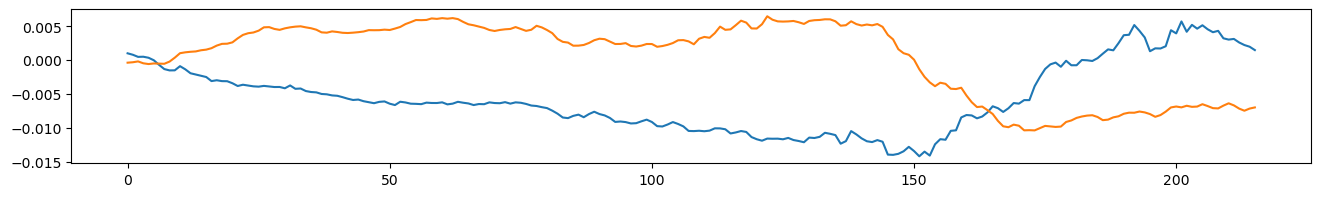

0.014193776990023027 0.010366840349369884


In [8]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.06985546116755006
KS for lead time 2h: 0.0671201844170185


KS for lead time 3h: 0.05164764370703823
KS for lead time 4h: 0.05404745518230286


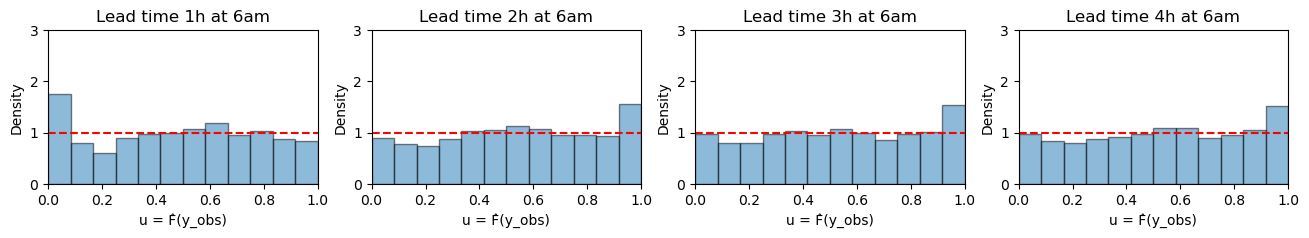

KS over lead times: 0.24267074447390966


In [9]:
lead = 1
bins = 12
ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = bins, 
              title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 1h: 0.03655876951331499
KS for lead time 2h: 0.02964876033057852
KS for lead time 3h: 0.02318009736808435
KS for lead time 4h: 0.04135879106883433
KS for lead time 5h: 0.06093893480257116
KS for lead time 6h: 0.04466253443526169


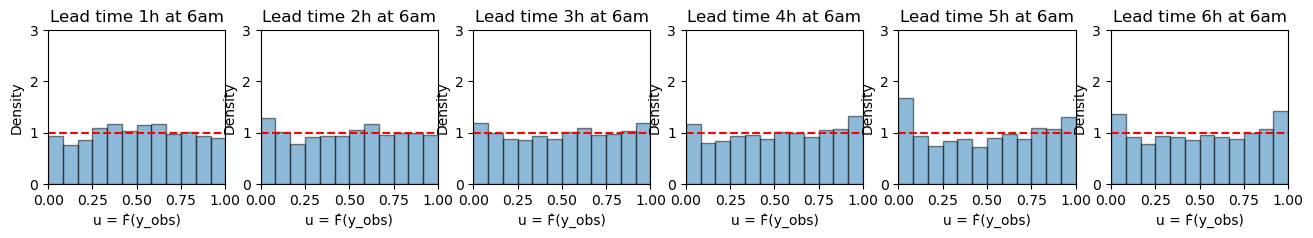

KS over lead times: 0.23634788751864505


In [10]:
lead = 1
bins = 12
ttl = 0.
n_intervals = 6

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*6:(i + lead + 1)*6].flatten(), 
            bins = bins, 
            title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*6:(i + lead + 1)*6].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

In [11]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

time = 216

M_, f_hat_, focal_, date_ = _run_parallel(n_workers = 72, 
                                          assets_ = range(20, 40, 1), 
                                          indices_ = range(363))

                     72       144      216
parameter                                 
forget_rate_f     0.1250    0.125    0.125
forget_rate_e     8.0000    4.000    2.000
lookup_rate     128.0000  128.000  128.000
length_scale_f    0.0100    0.005    0.001
length_scale_e    0.0075    0.025    0.010
trust_rate        0.4000    0.500    0.600
nu               14.0000   12.000   10.000
xi                0.8000    0.700    0.500
gamma            30.0000   50.000   30.000
kappa_min        80.0000  100.000  120.000
kappa_max       175.0000  175.000  175.000
p_fusion          0.6000    0.600    0.600
7260 7260 7260 7260


In [12]:
U_ = []
B_ = []
S_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
U_ = np.array(U_)
B_ = np.array(B_)
S_ = np.array(S_)
print(U_.shape, B_.shape, S_.shape)

df_3_ = pd.DataFrame({"date": date_, "std": S_})
df_3_[['asset', 'day', 'interval']] = df_3_['date'].str.split('-', expand=True)
df_3_.drop(columns = ['date'], inplace = True)
print(df_3_)

(7260, 72) (7260, 72) (7260,)
           std asset  day interval
0     0.106228    20    0      216
1     0.093441    20    1      216
2     0.084865    20    2      216
3     0.185634    20    3      216
4     0.138029    20    4      216
...        ...   ...  ...      ...
7255  0.166899    39  358      216
7256  0.203179    39  359      216
7257  0.094601    39  360      216
7258  0.089171    39  361      216
7259  0.076920    39  362      216

[7260 rows x 4 columns]


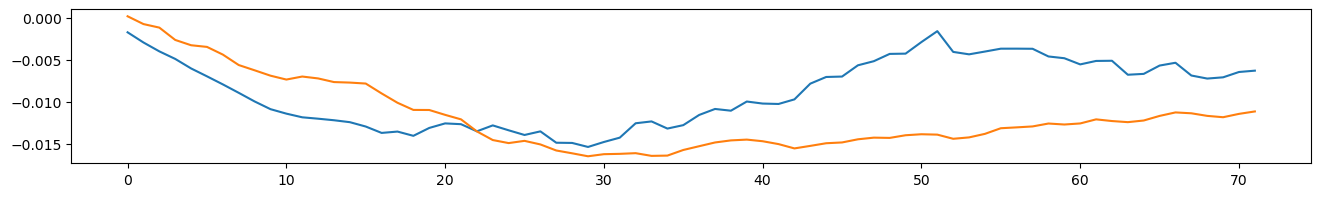

0.015389537263855602 0.016497978943346224


In [13]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.08199023256783507
KS for lead time 2h: 0.049292244156800114
KS for lead time 3h: 0.0472451790633609
KS for lead time 4h: 0.08111275828543085


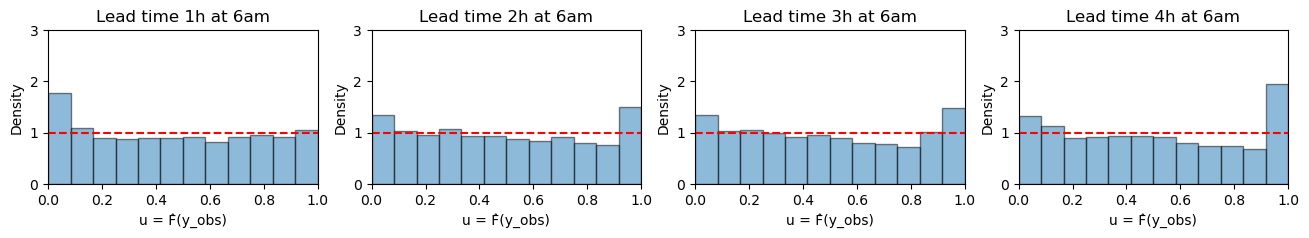

KS over lead times: 0.2596404140734269


In [14]:
lead = 1
bins = 12
ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = bins, 
              title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')
    
plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 1h: 0.04612029384756655
KS for lead time 2h: 0.06590909090909092
KS for lead time 3h: 0.060192837465564725
KS for lead time 4h: 0.05179063360881542
KS for lead time 5h: 0.06380142562681373
KS for lead time 6h: 0.05176767676767677


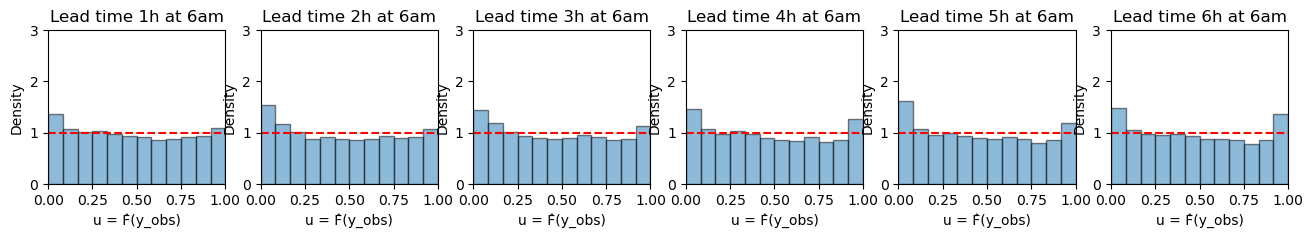

KS over lead times: 0.33958195822552817


In [15]:
lead = 1
bins = 12
ttl = 0.
n_intervals = 6

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*6:(i + lead + 1)*6].flatten(), 
            bins = bins, 
            title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*6:(i + lead + 1)*6].flatten())
    ttl += KS
    
    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

In [16]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

time = 144

M_, f_hat_, focal_, date_ = _run_parallel(n_workers = 72, 
                                          assets_ = range(20, 40, 1), 
                                          indices_ = range(363))

                     72       144      216
parameter                                 
forget_rate_f     0.1250    0.125    0.125
forget_rate_e     8.0000    4.000    2.000
lookup_rate     128.0000  128.000  128.000
length_scale_f    0.0100    0.005    0.001
length_scale_e    0.0075    0.025    0.010
trust_rate        0.4000    0.500    0.600
nu               14.0000   12.000   10.000
xi                0.8000    0.700    0.500
gamma            30.0000   50.000   30.000
kappa_min        80.0000  100.000  120.000
kappa_max       175.0000  175.000  175.000
p_fusion          0.6000    0.600    0.600


7260 7260 7260 7260


In [17]:
U_ = []
B_ = []
S_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
U_ = np.array(U_)
B_ = np.array(B_)
S_ = np.array(S_)
print(U_.shape, B_.shape, S_.shape)

df_2_ = pd.DataFrame({"date": date_, "std": S_})
df_2_[['asset', 'day', 'interval']] = df_2_['date'].str.split('-', expand=True)
df_2_.drop(columns = ['date'], inplace = True)
print(df_2_)

(7260, 144) (7260, 144) (7260,)
           std asset  day interval
0     0.068514    20    0      144
1     0.065223    20    1      144
2     0.072167    20    2      144
3     0.127204    20    3      144
4     0.103177    20    4      144
...        ...   ...  ...      ...
7255  0.145687    39  358      144
7256  0.153184    39  359      144
7257  0.169026    39  360      144
7258  0.098150    39  361      144
7259  0.053683    39  362      144

[7260 rows x 4 columns]


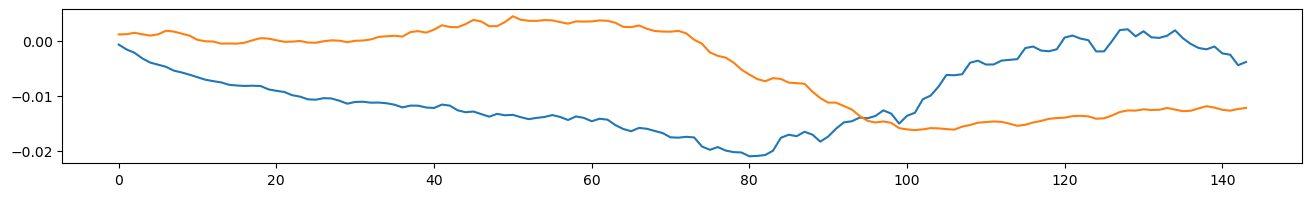

0.021036276865804227 0.016251130889292958


In [18]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.12107438016528928
KS for lead time 2h: 0.024801259346713844
KS for lead time 3h: 0.024763040831081495


KS for lead time 4h: 0.03148760330578504


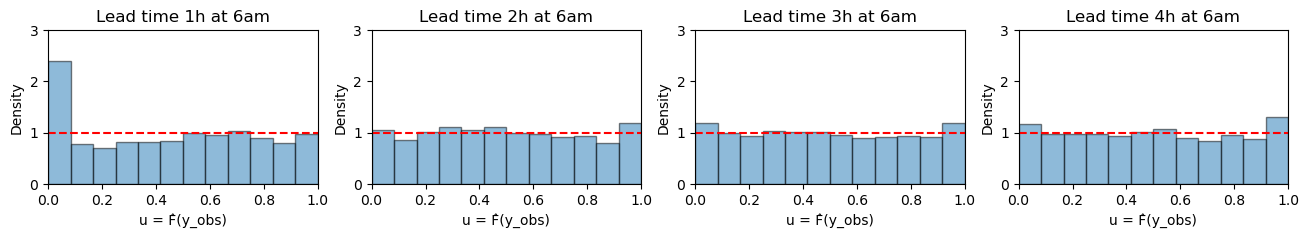

KS over lead times: 0.20212628364886964


In [19]:
lead = 1
bins = 12
ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = bins, 
              title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')
    
plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 1h: 0.03182736455463725
KS for lead time 2h: 0.0775938824473508
KS for lead time 3h: 0.056940365188619224
KS for lead time 4h: 0.03808845062530464
KS for lead time 5h: 0.08089137099092764
KS for lead time 6h: 0.05356702025673617


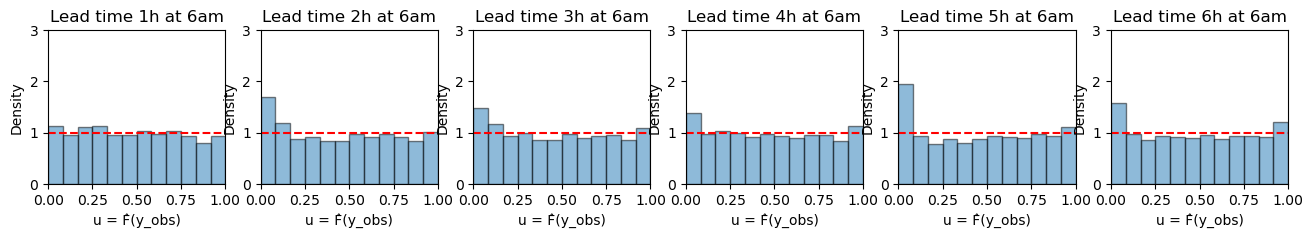

KS over lead times: 0.33890845406357567


In [20]:
lead = 1
bins = 12
ttl = 0.
n_intervals = 6

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*6:(i + lead + 1)*6].flatten(), 
            bins = bins, 
            title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*6:(i + lead + 1)*6].flatten())
    ttl += KS
    
    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

In [21]:
df_ = pd.concat([df_1_, df_2_, df_3_], axis = 0)    
print(df_.shape)

df_.to_csv(path_to_validation + f'/{resource}_{method}_dispersion-2.csv', index = False)

(21780, 4)
